# ARTI406 - Assignment 2: Data Quality Assessment and Preprocessing

**Dataset:** Chocolate Sales dataset  

This notebook completes the required tasks:
1. Identify data quality issues in the dataset.
2. Apply one missing value strategy and explain why.
3. Detect and handle outliers using IQR.
4. Normalize numerical features using both Min-Max and Z-score.
5. Apply PCA and interpret explained variance.

## Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Load Dataset

In [16]:
# The dataset file should be in the same folder as this notebook.
df = pd.read_csv('Chocolate_Sales.csv')

print('Dataset shape:', df.shape)
df.head(10)

Dataset shape: (3284, 6)


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,NaN,Mint Chip Choco,04-01-2022,"$5,320.00",180
1,Jehu Rudeforth,UK,Mint Chip Choco,04-01-2022,"$5,320.00",180
2,Van Tuxwell,India,85% Dark Bars,01-08-2022,"$7,896.00",94
3,Gigi Bohling,India,Peanut Butter Cubes,07-07-2022,"$4,501.00",91
4,Jan Morforth,Australia,Peanut Butter Cubes,27-04-2022,"$12,726.00",342
5,Jehu Rudeforth,UK,Peanut Butter Cubes,24-02-2022,"$13,685.00",184
6,Van Tuxwell,India,Smooth Sliky Salty,06-06-2022,"$5,376.00",38
7,Oby Sorrel,UK,99% Dark & Pure,25-01-2022,"$13,685.00",176
8,Gunar Cockshoot,Australia,After Nines,24-03-2022,"$3,080.00",73
9,Jehu Rudeforth,New Zealand,50% Dark Bites,20-04-2022,"$3,990.00",59


# Task 1 - Identify Data Quality Issues

In this task, we check missing values, duplicates, data types, invalid dates, and numeric columns stored as text.

In [17]:
print('Column data types before cleaning:')
display(df.dtypes.to_frame('Data Type'))

print()
print('Missing values per column:')
display(df.isna().sum().to_frame('Missing Values'))

print()
print('Number of duplicated rows:', df.duplicated().sum())

# Convert Amount from currency text to numeric for checking.
df_quality = df.copy()
df_quality['Amount_numeric'] = (
    df_quality['Amount']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Convert Date using day-first format because the dataset values are like 27-04-2022.
df_quality['Date_converted'] = pd.to_datetime(df_quality['Date'], dayfirst=True, errors='coerce')

quality_summary = pd.DataFrame({
    'Issue Checked': [
        'Missing values',
        'Duplicated rows',
        'Amount stored as object/text',
        'Date stored as object/text',
        'Invalid dates after conversion'
    ],
    'Result': [
        f"{df.isna().sum().sum()} total missing value(s); Country has {df['Country'].isna().sum()} missing value(s)",
        f"{df.duplicated().sum()} duplicated row(s)",
        f"Original Amount dtype = {df['Amount'].dtype}; converted successfully to numeric",
        f"Original Date dtype = {df['Date'].dtype}; converted to datetime using dayfirst=True",
        f"{df_quality['Date_converted'].isna().sum()} invalid date(s)"
    ]
})

display(quality_summary)

display(df_quality[['Amount_numeric', 'Boxes Shipped']].describe())

Column data types before cleaning:


,Data Type
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64



Missing values per column:


,Missing Values
Sales Person,0
Country,1
Product,0
Date,0
Amount,0
Boxes Shipped,0



Number of duplicated rows: 1


,Issue Checked,Result
0,Missing values,1 total missing value(s); Country has 1 missin...
1,Duplicated rows,1 duplicated row(s)
2,Amount stored as object/text,Original Amount dtype = object; converted succ...
3,Date stored as object/text,Original Date dtype = object; converted to dat...
4,Invalid dates after conversion,0 invalid date(s)


,Amount_numeric,Boxes Shipped
count,"3,284.0000","3,284.0000"
mean,"6,028.7253",164.7086
std,"4,393.3887",124.0053
min,7.0000,1.0000
25%,"2,519.6250",71.0000
50%,"5,225.5000",137.0000
75%,"8,553.3475",232.0000
max,"26,170.9500",778.0000


**Task 1 interpretation:**  
The dataset has one missing value in `Country`, one duplicated row, and two columns that need type conversion: `Amount` is stored as currency text and `Date` is stored as text. After converting `Amount` to numeric and `Date` to datetime using `dayfirst=True`, there are no invalid dates.

# Task 2 - Apply One Missing Value Strategy and Explain Why

The missing value is in `Country`, which is a categorical column. I used **mode imputation** because the mode is the most frequent category and is suitable for categorical data when the number of missing values is very small.

In [18]:
# Start the cleaned dataset from the quality-check version.
df_clean = df_quality.copy()

# Remove exact duplicated rows.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

country_mode = df_clean['Country'].mode()[0]
missing_before = df_clean['Country'].isna().sum()

df_clean['Country'] = df_clean['Country'].fillna(country_mode)
missing_after = df_clean['Country'].isna().sum()

missing_strategy_summary = pd.DataFrame({
    'Column': ['Country'],
    'Missing Before': [missing_before],
    'Strategy': ['Mode imputation'],
    'Value Used': [country_mode],
    'Missing After': [missing_after],
    'Reason': ['Country is categorical and only one value is missing, so using the most frequent country is reasonable.']
})

display(missing_strategy_summary)
print('Cleaned dataset shape after removing duplicated rows:', df_clean.shape)

,Column,Missing Before,Strategy,Value Used,Missing After,Reason
0,Country,1,Mode imputation,Australia,0,Country is categorical and only one value is m...


Cleaned dataset shape after removing duplicated rows: (3283, 8)


# Task 3 - Detect and Handle Outliers Using IQR

IQR rule:

\[
IQR = Q3 - Q1
\]

\[
Lower\ Bound = Q1 - 1.5 	imes IQR
\]

\[
Upper\ Bound = Q3 + 1.5 	imes IQR
\]

Values outside the lower and upper bounds are considered outliers. I handled them using **capping**, which replaces values below the lower bound with the lower bound and values above the upper bound with the upper bound. This keeps all rows while reducing the effect of extreme values.

In [19]:
numeric_cols = ['Amount_numeric', 'Boxes Shipped']

iqr_results = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_count = outlier_mask.sum()

    df_clean[col + '_IQR_capped'] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    outlier_count_after = ((df_clean[col + '_IQR_capped'] < lower_bound) | (df_clean[col + '_IQR_capped'] > upper_bound)).sum()

    iqr_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Before': outlier_count,
        'Outliers After Capping': outlier_count_after
    })

iqr_summary = pd.DataFrame(iqr_results)
display(iqr_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Before,Outliers After Capping
0,Amount_numeric,"2,522.9900","8,555.0950","6,032.1050","-6,525.1675","17,603.2525",50,0
1,Boxes Shipped,71.0000,232.0000,161.0000,-170.5000,473.5000,78,0


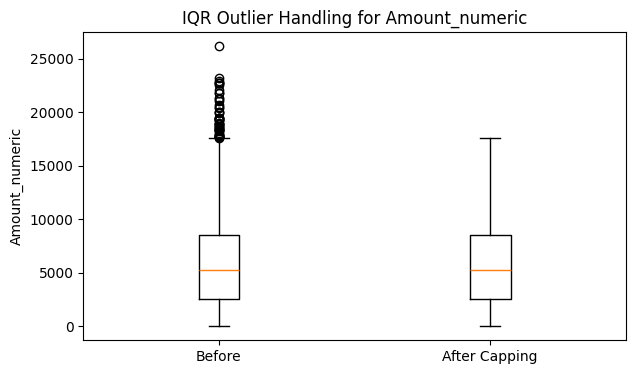

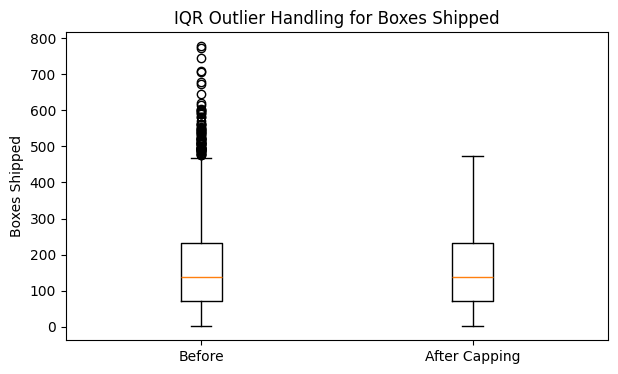

In [20]:
# Boxplots before and after outlier capping
for col in numeric_cols:
    capped_col = col + '_IQR_capped'
    plt.figure(figsize=(7, 4))
    plt.boxplot(
        [df_clean[col], df_clean[capped_col]],
        tick_labels=['Before', 'After Capping']
    )
    plt.title(f'IQR Outlier Handling for {col}')
    plt.ylabel(col)
    plt.show()

**Task 3 interpretation:**  
Using IQR, `Amount_numeric` has 50 outliers and `Boxes Shipped` has 78 outliers. The outliers were handled by capping, so after handling there are 0 values outside the IQR bounds.

# Task 4 - Normalize Numerical Features Using Both Min-Max and Z-score

Two normalization methods were applied to the IQR-capped numerical features:

- **Min-Max normalization:** scales values to the range 0 to 1.
- **Z-score standardization:** transforms values to have mean approximately 0 and standard deviation approximately 1.

In [21]:
features_for_scaling = ['Amount_numeric_IQR_capped', 'Boxes Shipped_IQR_capped']

minmax_scaler = MinMaxScaler()
zscore_scaler = StandardScaler()

minmax_values = minmax_scaler.fit_transform(df_clean[features_for_scaling])
zscore_values = zscore_scaler.fit_transform(df_clean[features_for_scaling])

minmax_df = pd.DataFrame(minmax_values, columns=[col + '_MinMax' for col in features_for_scaling])
zscore_df = pd.DataFrame(zscore_values, columns=[col + '_Zscore' for col in features_for_scaling])

scaled_df = pd.concat([df_clean[features_for_scaling], minmax_df, zscore_df], axis=1)

display(scaled_df.head(10))

normalization_check = pd.DataFrame({
    'Feature': features_for_scaling,
    'MinMax Minimum': minmax_values.min(axis=0),
    'MinMax Maximum': minmax_values.max(axis=0),
    'Z-score Mean': zscore_values.mean(axis=0),
    'Z-score Std': zscore_values.std(axis=0)
})

display(normalization_check)

,Amount_numeric_IQR_capped,Boxes Shipped_IQR_capped,Amount_numeric_IQR_capped_MinMax,Boxes Shipped_IQR_capped_MinMax,Amount_numeric_IQR_capped_Zscore,Boxes Shipped_IQR_capped_Zscore
0,"5,320.0000",180.0000,0.3019,0.3788,-0.1579,0.1442
1,"5,320.0000",180.0000,0.3019,0.3788,-0.1579,0.1442
2,"7,896.0000",94.0000,0.4483,0.1968,0.4425,-0.5816
3,"4,501.0000",91.0000,0.2554,0.1905,-0.3487,-0.6069
4,"12,726.0000",342.0000,0.7228,0.7217,1.5682,1.5115
5,"13,685.0000",184.0000,0.7773,0.3873,1.7917,0.1780
6,"5,376.0000",38.0000,0.3051,0.0783,-0.1448,-1.0542
7,"13,685.0000",176.0000,0.7773,0.3704,1.7917,0.1105
8,"3,080.0000",73.0000,0.1746,0.1524,-0.6799,-0.7588
9,"3,990.0000",59.0000,0.2264,0.1228,-0.4678,-0.8770


,Feature,MinMax Minimum,MinMax Maximum,Z-score Mean,Z-score Std
0,Amount_numeric_IQR_capped,0.0000,1.0000,0.0000,1.0000
1,Boxes Shipped_IQR_capped,0.0000,1.0000,0.0000,1.0000


**Task 4 interpretation:**  
Min-Max normalization successfully scaled both numerical features between 0 and 1. Z-score standardization transformed both numerical features to have mean very close to 0 and standard deviation equal to 1.

# Task 5 - Apply PCA and Interpret Explained Variance

PCA was applied to the **Z-score standardized** numerical features because PCA is affected by feature scale. Since there are two numerical features, PCA returns two principal components.

In [22]:
pca = PCA(n_components=2)
pca_values = pca.fit_transform(zscore_values)

pca_df = pd.DataFrame(pca_values, columns=['PC1', 'PC2'])

explained_variance = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Variance': np.cumsum(pca.explained_variance_ratio_)
})

component_loadings = pd.DataFrame(
    pca.components_,
    columns=features_for_scaling,
    index=['PC1', 'PC2']
)

print('Explained variance:')
display(explained_variance)

print('PCA component loadings:')
display(component_loadings)

print('First 10 PCA rows:')
display(pca_df.head(10))

Explained variance:


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.5059,0.5059
1,PC2,0.4941,1.0000


PCA component loadings:


,Amount_numeric_IQR_capped,Boxes Shipped_IQR_capped
PC1,0.7071,-0.7071
PC2,0.7071,0.7071


First 10 PCA rows:


,PC1,PC2
0,-0.2136,-0.0096
1,-0.2136,-0.0096
2,0.7241,-0.0983
3,0.1826,-0.6757
4,0.0401,2.1777
5,1.1411,1.3928
6,0.6431,-0.8478
7,1.1888,1.3451
8,0.0558,-1.0173
9,0.2893,-0.9509


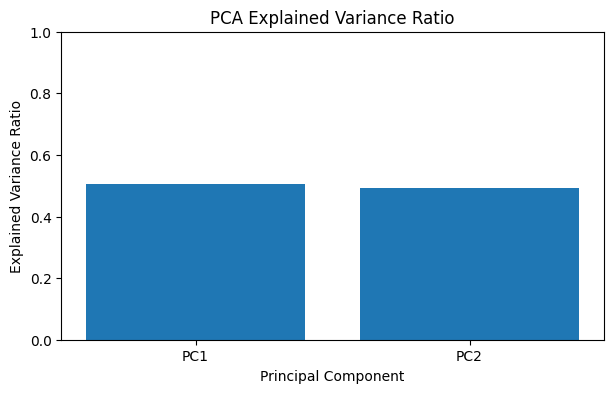

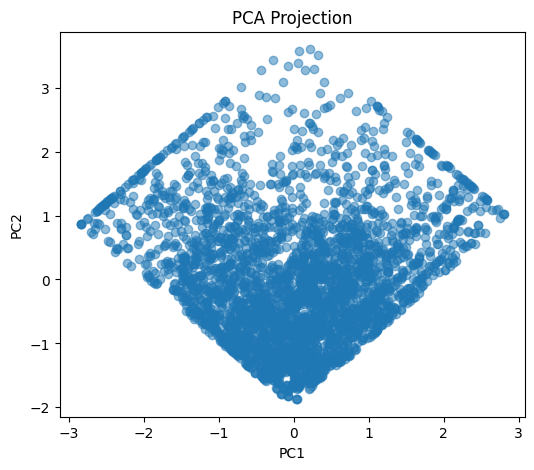

In [23]:
plt.figure(figsize=(7, 4))
plt.bar(explained_variance['Principal Component'], explained_variance['Explained Variance Ratio'])
plt.title('PCA Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

**Task 5 interpretation:**  
PC1 explains about 50.59% of the variance and PC2 explains about 49.41%. This means the two numerical features contribute almost equally to the dataset's numerical variation. Because PC1 alone explains only about half of the variance, keeping both components is better if we want to preserve nearly 100% of the variance.

# Final Cleaned Dataset Preview

In [24]:
final_df = pd.concat([df_clean, minmax_df, zscore_df, pca_df], axis=1)
print('Final dataset shape:', final_df.shape)
display(final_df.head(10))

# Save the processed dataset for reference.
final_df.to_csv('Chocolate_Sales_Assignment2_Processed.csv', index=False)
print('Processed dataset saved as Chocolate_Sales_Assignment2_Processed.csv')

Final dataset shape: (3283, 16)


,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Amount_numeric,Date_converted,Amount_numeric_IQR_capped,Boxes Shipped_IQR_capped,Amount_numeric_IQR_capped_MinMax,Boxes Shipped_IQR_capped_MinMax,Amount_numeric_IQR_capped_Zscore,Boxes Shipped_IQR_capped_Zscore,PC1,PC2
0,Jehu Rudeforth,Australia,Mint Chip Choco,04-01-2022,"$5,320.00",180,"5,320.0000",2022-01-04,"5,320.0000",180.0000,0.3019,0.3788,-0.1579,0.1442,-0.2136,-0.0096
1,Jehu Rudeforth,UK,Mint Chip Choco,04-01-2022,"$5,320.00",180,"5,320.0000",2022-01-04,"5,320.0000",180.0000,0.3019,0.3788,-0.1579,0.1442,-0.2136,-0.0096
2,Van Tuxwell,India,85% Dark Bars,01-08-2022,"$7,896.00",94,"7,896.0000",2022-08-01,"7,896.0000",94.0000,0.4483,0.1968,0.4425,-0.5816,0.7241,-0.0983
3,Gigi Bohling,India,Peanut Butter Cubes,07-07-2022,"$4,501.00",91,"4,501.0000",2022-07-07,"4,501.0000",91.0000,0.2554,0.1905,-0.3487,-0.6069,0.1826,-0.6757
4,Jan Morforth,Australia,Peanut Butter Cubes,27-04-2022,"$12,726.00",342,"12,726.0000",2022-04-27,"12,726.0000",342.0000,0.7228,0.7217,1.5682,1.5115,0.0401,2.1777
5,Jehu Rudeforth,UK,Peanut Butter Cubes,24-02-2022,"$13,685.00",184,"13,685.0000",2022-02-24,"13,685.0000",184.0000,0.7773,0.3873,1.7917,0.1780,1.1411,1.3928
6,Van Tuxwell,India,Smooth Sliky Salty,06-06-2022,"$5,376.00",38,"5,376.0000",2022-06-06,"5,376.0000",38.0000,0.3051,0.0783,-0.1448,-1.0542,0.6431,-0.8478
7,Oby Sorrel,UK,99% Dark & Pure,25-01-2022,"$13,685.00",176,"13,685.0000",2022-01-25,"13,685.0000",176.0000,0.7773,0.3704,1.7917,0.1105,1.1888,1.3451
8,Gunar Cockshoot,Australia,After Nines,24-03-2022,"$3,080.00",73,"3,080.0000",2022-03-24,"3,080.0000",73.0000,0.1746,0.1524,-0.6799,-0.7588,0.0558,-1.0173
9,Jehu Rudeforth,New Zealand,50% Dark Bites,20-04-2022,"$3,990.00",59,"3,990.0000",2022-04-20,"3,990.0000",59.0000,0.2264,0.1228,-0.4678,-0.8770,0.2893,-0.9509


Processed dataset saved as Chocolate_Sales_Assignment2_Processed.csv
